# 02: Behavioural metrics

Derived purely from the translation run (no DB, no reference query): Pass@1, Pass@k, mean iterations, mean duration, tokens, and cost. Computed overall and stratified by `(dataset, target, model)` and by difficulty. Reads every `records_*.json` so it covers the whole matrix.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "evaluation"))

import pandas as pd
from eval_harness import load_records, OUTPUTS_DIR, usd_cost, billed_input_tokens

OUT_CSV = OUTPUTS_DIR / 'metrics_behavioural.csv'
records = load_records(OUTPUTS_DIR)
assert records, 'No records found. Run 01_translation_run.ipynb first.'
df = pd.DataFrame(records)
print(f'Loaded {len(df)} records from {OUTPUTS_DIR}')

Loaded 56 records from /Users/ivona.obonova/school/rows2graph/rows2graph/evaluation/outputs


## Pricing

USD per million tokens, by provider. Local Ollama is free; the Anthropic rates are Opus-class placeholders -- refine per model when an Anthropic row is added.

In [2]:
# Pricing + cache multipliers live in eval_harness.pricing (usd_cost /
# billed_input_tokens are imported in the first cell) so this notebook,
# notebook 06, and the tests share one source of truth. Anthropic caches the
# system prompt, so cost must price the cache_creation / cache_read buckets,
# not just the uncached input_tokens.
from eval_harness.pricing import (
    MODEL_PRICING, PROVIDER_DEFAULT_PRICING, CACHE_WRITE_MULT, CACHE_READ_MULT,
)

print('Model rates (USD/Mtok, input / output):')
for _m, (_pin, _pout) in MODEL_PRICING.items():
    print(f'  {_m:20} {_pin:>5} / {_pout:>5}')
print('Provider fallback:', PROVIDER_DEFAULT_PRICING)
print(f'Anthropic cache: write x{CACHE_WRITE_MULT}, read x{CACHE_READ_MULT} of the input rate')

Model rates (USD/Mtok, input / output):
  claude-opus-4-8        5.0 /  25.0
  claude-opus-4-7        5.0 /  25.0
  claude-sonnet-4-6      3.0 /  15.0
  claude-haiku-4-5       1.0 /   5.0
  claude-fable-5        10.0 /  50.0
Provider fallback: {'ollama': (0.0, 0.0), 'anthropic': (5.0, 25.0)}
Anthropic cache: write x1.25, read x0.1 of the input rate


## Per-record signals

In [3]:
df['pass_at_1'] = df['validation_passed'] & (df['iterations_used'] == 1)
# Anthropic bills the cached prompt in cache_read / cache_creation; the true
# prompt size (and the platform.claude.com "tokens in") is the sum of all three.
df['billed_input_tokens'] = df['input_tokens'] + df['cache_read_tokens'] + df['cache_creation_tokens']
df['cost_usd'] = df.apply(lambda r: usd_cost(
    r['provider'], r['model'], r['input_tokens'], r['output_tokens'],
    r['cache_read_tokens'], r['cache_creation_tokens']), axis=1)
df[['dataset','target','model','query_id','iterations_used','validation_passed',
    'pass_at_1','billed_input_tokens','output_tokens','cost_usd']].head(10)

,dataset,target,model,query_id,iterations_used,validation_passed,pass_at_1,billed_input_tokens,output_tokens,cost_usd
0,ldbc,cypher,claude-opus-4-8,ldbc_q01,1,True,True,3825,50,0.025085
1,ldbc,cypher,claude-opus-4-8,ldbc_q02,1,True,True,4566,87,0.030624
2,ldbc,cypher,claude-opus-4-8,ldbc_q03,1,True,True,3823,45,0.003284
3,ldbc,cypher,claude-opus-4-8,ldbc_q04,1,True,True,5186,76,0.034169
4,ldbc,cypher,claude-opus-4-8,ldbc_q05,1,True,True,5709,96,0.037882
5,ldbc,cypher,claude-opus-4-8,ldbc_q06,1,True,True,4385,73,0.029084
6,ldbc,cypher,claude-opus-4-8,ldbc_q07,1,True,True,5152,140,0.035502
7,ldbc,cypher,claude-opus-4-8,ldbc_q08,1,True,True,4592,151,0.032151
8,ldbc,cypher,claude-opus-4-8,ldbc_q09,1,True,True,4572,118,0.031371
9,ldbc,cypher,claude-opus-4-8,ldbc_q10,1,True,True,5188,89,0.005346


## Aggregation

In [4]:
MAX_ITERATIONS = int(df['iterations_used'].max()) if len(df) else 0

def aggregate(group):
    successes = group['validation_passed'].sum()
    return pd.Series({
        'n': len(group),
        'pass@1': group['pass_at_1'].mean(),
        f'pass@{MAX_ITERATIONS}': group['validation_passed'].mean(),
        'mean_iterations': group['iterations_used'].mean(),
        'mean_duration_s': group['duration_seconds'].mean(),
        'total_input_tok': int(group['billed_input_tokens'].sum()),
        'total_uncached_input_tok': int(group['input_tokens'].sum()),
        'total_output_tok': int(group['output_tokens'].sum()),
        'total_cost_usd': group['cost_usd'].sum(),
        'cost_per_success_usd': group['cost_usd'].sum() / successes if successes else float('nan'),
    })

aggregate(df).to_frame('overall').T

,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_uncached_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
overall,56.0,0.964286,1.0,1.071429,10.440933,206331.0,142025.0,27837.0,0.363825,0.006497


## Stratified by dataset x target x model

In [5]:
df.groupby(['dataset','target','model'], group_keys=False).apply(aggregate)

n    pass@1  pass@3  mean_iterations  \
dataset target model                                                      
ldbc    cypher claude-opus-4-8  14.0  1.000000     1.0         1.000000   
               gemma4:26b       14.0  1.000000     1.0         1.000000   
               llama3.2:latest  14.0  0.857143     1.0         1.285714   
               qwen3-coder:30b  14.0  1.000000     1.0         1.000000   

                                mean_duration_s  total_input_tok  \
dataset target model                                               
ldbc    cypher claude-opus-4-8         2.982038          66040.0   
               gemma4:26b             25.378478          46127.0   
               llama3.2:latest         7.469851          53254.0   
               qwen3-coder:30b         5.933367          40910.0   

                                total_uncached_input_tok  total_output_tok  \
dataset target model                                                         
ldbc    cypher claude-opus-4-8                    1734.0            1329.0   
               gemma4:26b                        46127.0           23720.0   
               llama3.2:latest                   53254.0            1955.0   
               qwen3-coder:30b                   40910.0             833.0   

                                total_cost_usd  cost_per_success_usd  
dataset target model                                                  
ldbc    cypher claude-opus-4-8        0.363825              0.025988  
               gemma4:26b             0.000000              0.000000  
               llama3.2:latest        0.000000              0.000000  
               qwen3-coder:30b        0.000000              0.000000

## Stratified by difficulty

In [6]:
df.groupby('difficulty', group_keys=False).apply(aggregate).reindex(['easy','medium','hard'])

,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_uncached_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
difficulty,,,,,,,,,,
easy,12.0,0.916667,1.0,1.166667,14.750065,42353.0,30322.0,2740.0,0.058993,0.004916
medium,16.0,1.000000,1.0,1.000000,8.003245,56201.0,37602.0,7611.0,0.128969,0.008061
hard,28.0,0.964286,1.0,1.071429,9.987127,107777.0,74101.0,17486.0,0.175864,0.006281


## Save per-record CSV

In [7]:
out = df[['dataset','target','model','provider','query_id','difficulty',
          'validation_passed','pass_at_1','iterations_used','duration_seconds',
          'input_tokens','output_tokens','cache_read_tokens','cache_creation_tokens',
          'billed_input_tokens','cost_usd']].copy()
out.to_csv(OUT_CSV, index=False)
print(f'Wrote {len(out)} rows to {OUT_CSV}')

Wrote 56 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/evaluation/outputs/metrics_behavioural.csv


## Visualizations: all models / all queries

Behavioural metrics cover every model, so these are fully populated: a per-query pass/fail matrix, per-model pass rates, cost & latency, and pass rate by difficulty. Figures are written to `reports/figures/` and shown inline.

In [8]:
from eval_harness import plots, REPORTS_DIR
FIG_DIR = REPORTS_DIR / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS = plots.model_axis(df); QUERIES = plots.query_axis(df)
print(f'{len(MODELS)} model(s): {MODELS}')
print(f'{len(QUERIES)} query id(s): {QUERIES}')

4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']
14 query id(s): ['ldbc_q01', 'ldbc_q02', 'ldbc_q03', 'ldbc_q04', 'ldbc_q05', 'ldbc_q06', 'ldbc_q07', 'ldbc_q08', 'ldbc_q09', 'ldbc_q10', 'ldbc_q11', 'ldbc_q12', 'ldbc_q13', 'ldbc_q14']


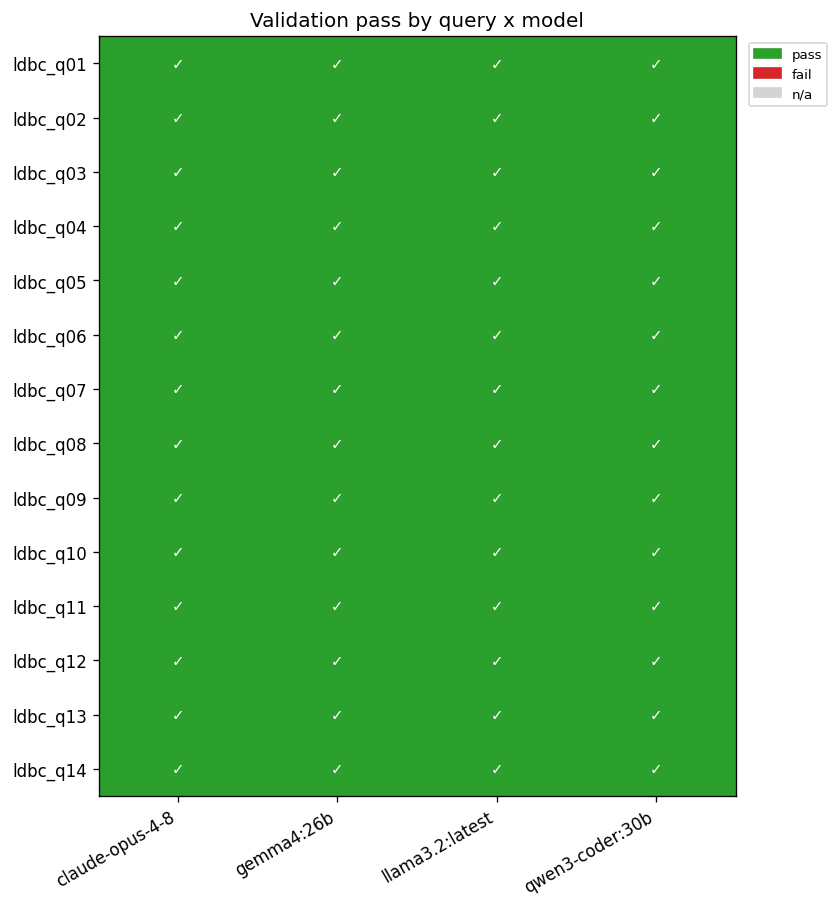

In [9]:
# The all-queries view: did each model produce a valid query, per query?
# validation_passed exists for every model, so this grid is fully populated.
p = FIG_DIR / 'query_model_pass.png'
plots.query_model_heatmap(df, 'validation_passed', p, discrete=True, models=MODELS, queries=QUERIES,
                          title='Validation pass by query x model', cbar_label='pass')
plots.show(p)

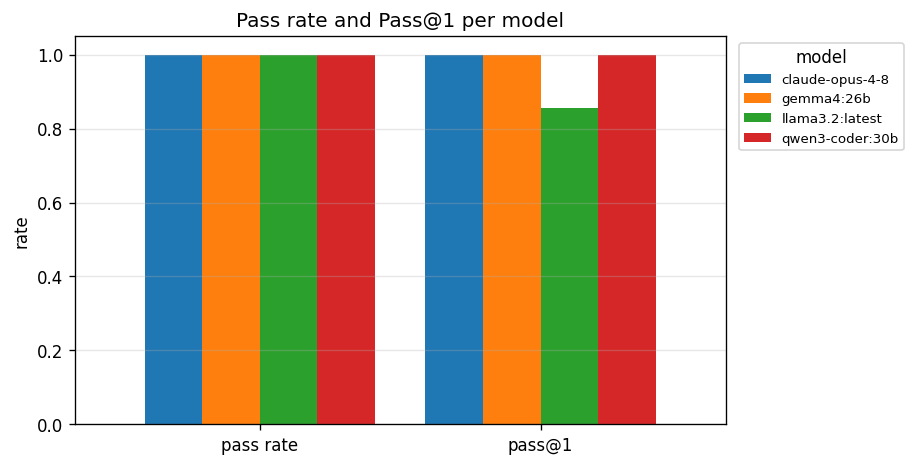

In [10]:
# Per-model pass rate (any iteration) and Pass@1 (first try).
p = FIG_DIR / 'behavioural_pass_bars.png'
plots.per_model_bars(df, ['validation_passed', 'pass_at_1'], p, title='Pass rate and Pass@1 per model',
                     ylabel='rate', labels={'validation_passed': 'pass rate', 'pass_at_1': 'pass@1'})
plots.show(p)

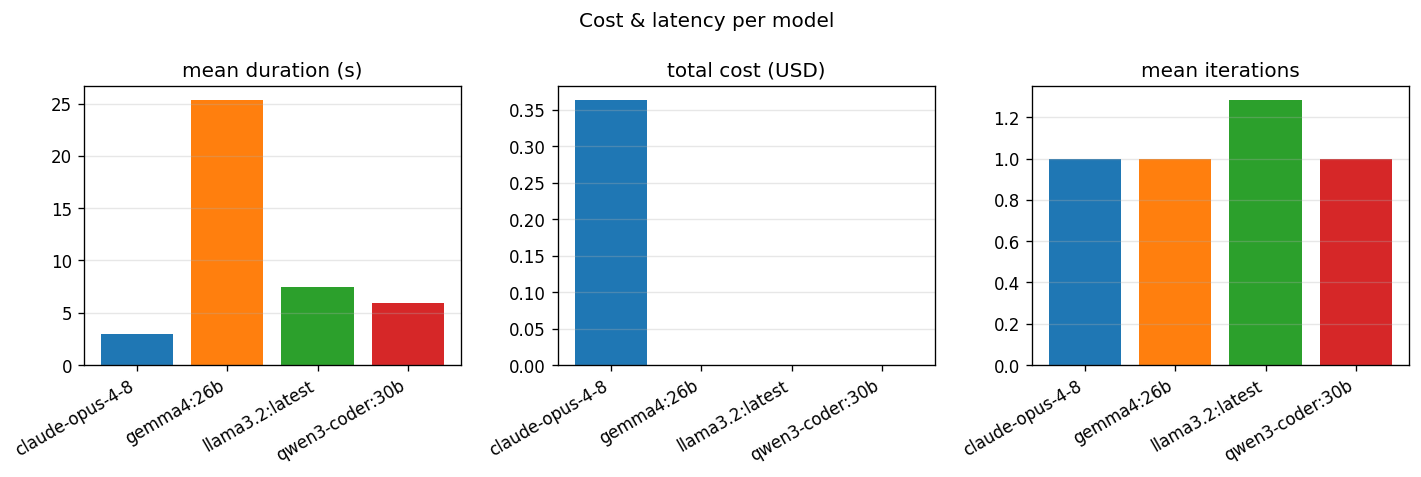

In [11]:
# Operational cost of each model: mean duration, total USD, mean fix iterations.
p = FIG_DIR / 'cost_latency.png'
plots.cost_latency(df, p); plots.show(p)

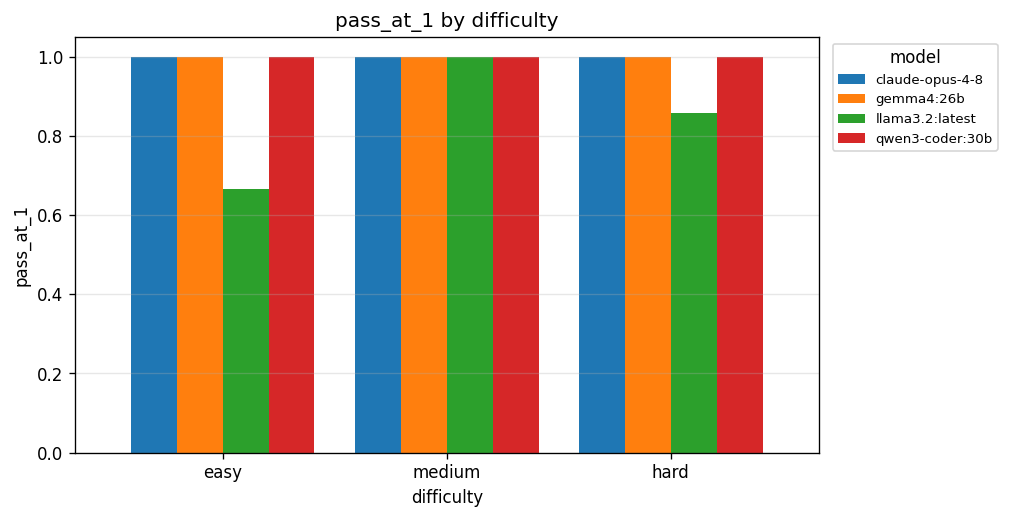

In [12]:
# Does a model degrade on harder queries? Pass@1 by difficulty, grouped by model.
p = FIG_DIR / 'passrate_by_difficulty.png'
plots.passrate_by_difficulty(df, 'pass_at_1', p); plots.show(p)